## Analyse connectomes

- atlases: AAL3_amended, Glasser, Glasser_hemiUnique
- look at mean connectome
- group comparison

- NBS: network based statistics? (original matlab toolbox, Melanie Ehrler used it in her paper with AAL3)
Identifying differences in brain networks: method to control the family-wise error rate (in the weak sense) when mass-univariate testing is performed at every connection comprising the graph. NBS exploits the extent to which the connections comprising the contrast or effect of interest are interconnected
    https://pypi.org/project/bctpy/ (translation of matlab code to python.)
    https://github.com/GidLev/NBS-correlation



(Atlas stuff in other script!)

In [24]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')
plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')

subList = [f'{i:02d}' for i in range(1, 67)]
sub_array= np.array([int(i) for i in subList]) 

bids_folder_orig ='/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()


In [25]:
atlas =  'Glasser_hemiUnique'#'Glasser' # 'AAL3_amended' #
CMs = []
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file, header=None) #header=0, index_col=0) was wrong before!!
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]

    C = np.array(connectome)
    C_scaled = (C + C.T) * mu_factor
    CMs.append(C_scaled)

print(np.shape(CMs))

cms = np.array(CMs)

(66, 360, 360)


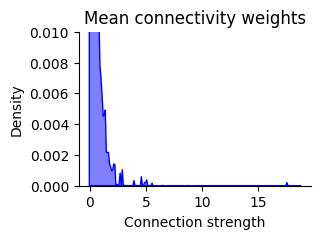

In [26]:
cm_mean = cms.mean(axis=0)

fig,ax = plt.subplots(figsize=(3,2))
sns.kdeplot(cm_mean.flatten(),fill=True, color='blue', alpha=0.5,ax=ax)
ax.set(ylim=(0, 0.01), title='Mean connectivity weights', xlabel='Connection strength', ylabel='Density')
sns.despine(ax=ax)

Text(0.5, 1.0, 'Mean connectivity weights \n Glasser_hemiUnique parcellation')

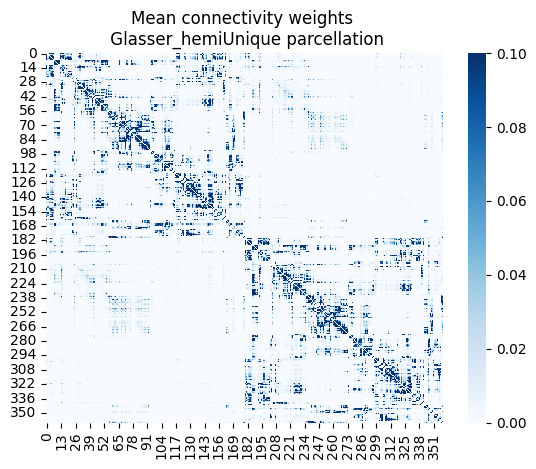

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = sns.heatmap(cm_mean,cmap = 'Blues', vmin=0, vmax=0.1)
fig.set_title(f'Mean connectivity weights \n {atlas} parcellation', fontsize=12)

#### reorder ROIs for AAL3_amended so hemispheres are seperate

In [8]:
# Atlas Annotations

atlas_names = pd.read_table('/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/AAL3/ROI_MNI_V7_1mm_vol.txt')                     
atlas_names.columns = ['label_abrv','label','parcel_N','parcel_size_voxels' ,'parcel_size_mm3']                         
atlas_names.set_index('parcel_N', inplace=True)
atlas_names

,label_abrv,label,parcel_size_voxels,parcel_size_mm3
parcel_N,,,,
1,FAL,Precentral_L,28208,28208
2,FAR,Precentral_R,27048,27048
3,F1_2L,Frontal_Sup_2_L,38960,38960
4,F1_2R,Frontal_Sup_2_R,41008,41008
5,F2_2L,Frontal_Mid_2_L,36056,36056
...,...,...,...,...
166,RedNR,Red_N_R,486,486
167,LCL,LC_L,48,48
168,LCR,LC_R,53,53


In [12]:
# Extract hemisphere info
def get_hemi(label):
    if label.endswith('_L'):
        return 'L'
    elif label.endswith('_R'):
        return 'R'
    else:
        return 'X'
    
atlas_names['hemi'] = atlas_names['label'].apply(get_hemi)


In [ ]:
# Get new order: L first, then R, then X
order = (
    list(atlas_names[atlas_names['hemi'] == 'L'].index) +
    list(atlas_names[atlas_names['hemi'] == 'R'].index) +
    list(atlas_names[atlas_names['hemi'] == 'X'].index)
)
order = np.array(order) -1 # -1 because of 0-indexing in Python

Text(0.5, 1.0, 'Mean connectivity weights \n AAL3_amended parcellation  \n ROIs reordered for Hemis')

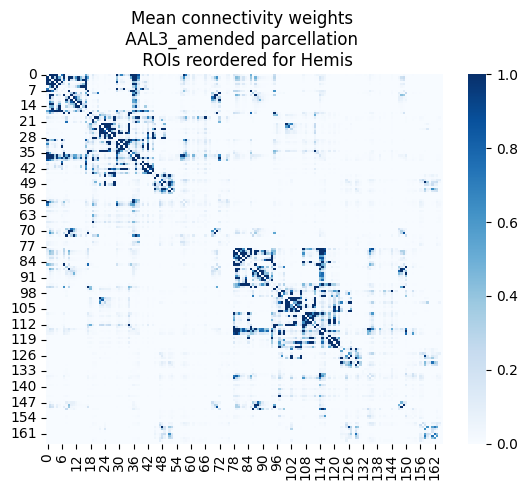

In [23]:
# reshuffel the matrix so that nodes of one hemisphere are at top and the other at the bottom
cm_mean_hemiROIssplit = cm_mean[np.ix_(order, order)]

fig = sns.heatmap(cm_mean_hemiROIssplit,cmap = 'Blues', vmin=0, vmax=1)
fig.set_title(f'Mean connectivity weights \n {atlas} parcellation  \n ROIs reordered for Hemis', fontsize=12)

## Group comparisons

In [30]:
# Compare all edges?!
from scipy.stats import ttest_ind

N_nodes = cm_mean.shape[0]

mat_tstats = np.full((N_nodes, N_nodes), np.nan)
mat_pvals = np.full((N_nodes, N_nodes), np.nan)

for node1 in range(N_nodes):
    for node2 in range(node1 + 1, N_nodes):
        conn_weights = cms[:, node1, node2]
        if conn_weights.mean() != 0 :
            df = pd.DataFrame(np.array(conn_weights), index=sub_array)
            df.index.name = 'subject'
            df = df.join(group_list).set_index('group',append=True)
            t_stat, p_val = ttest_ind(df.xs(0,0,'group'), df.xs(1,0,'group'), equal_var=False)  # Welch's t-test

            mat_tstats[node1,node2] = t_stat[0]
            mat_pvals[node1,node2] = p_val[0]

# 42 sec

Text(0.5, 1.0, 'T-statistic for group differences \n Glasser_hemiUnique parcellation')

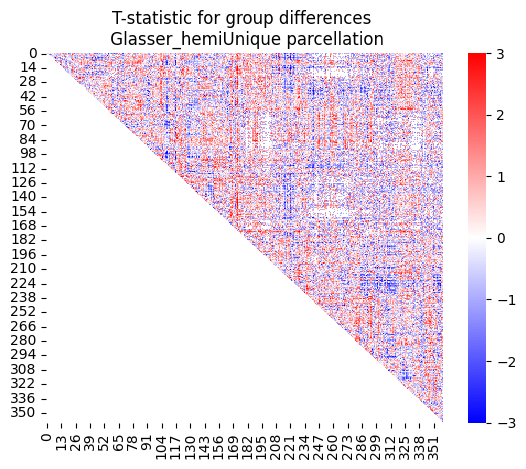

In [31]:
fig = sns.heatmap(mat_tstats,cmap = 'bwr', vmin=-3,vmax=3)
fig.set_title(f'T-statistic for group differences \n {atlas} parcellation', fontsize=12)

Text(0.5, 1.0, 'P-values for group differences \n Glasser_hemiUnique parcellation')

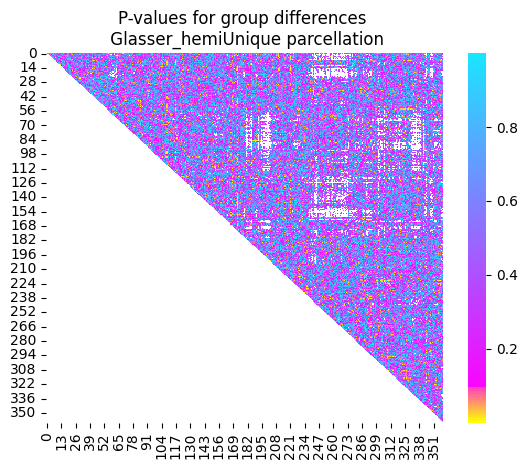

In [34]:
from utils import get_pval_colormap
pval_cmap = get_pval_colormap()

fig = sns.heatmap(mat_pvals,cmap = pval_cmap)
fig.set_title(f'P-values for group differences \n {atlas} parcellation', fontsize=12)

In [35]:
# get nodes with many significant connections ?

mat_tstats_comp = np.nansum(np.stack([mat_tstats, mat_tstats.T]), axis=0)
tstats_mean_nodes = np.nanmean(mat_tstats_comp, axis=0)

df_node_tstats = pd.DataFrame(tstats_mean_nodes, index=np.arange(1, N_nodes + 1), columns=['mean_Tstat'])
df_node_tstats.sort_values(by='mean_Tstat', ascending=False)

,mean_Tstat
174,1.247061
105,0.735805
86,0.719235
253,0.634968
60,0.633498
...,...
118,-0.662623
172,-0.681104
217,-0.747261
110,-0.783469


In [36]:
np.where(tstats_mean_nodes == tstats_mean_nodes.max())

(array([173]),)

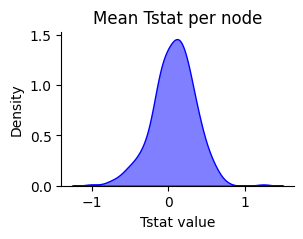

In [37]:
fig,ax = plt.subplots(figsize=(3,2))
sns.kdeplot(tstats_mean_nodes,fill=True, color='blue', alpha=0.5,ax=ax)
ax.set( title='Mean Tstat per node', xlabel='Tstat value', ylabel='Density')
sns.despine(ax=ax)

In [38]:
def get_glasser_CAatlas_mapping(datadir = '/mnt_03/diverse_neuralData/atlases_parcellations/ColeAnticevicNetPartition'):
    glasser_CAatlas_mapping = pd.read_csv(op.join(datadir,'cortex_parcel_network_assignments.txt'),header=None)
    glasser_CAatlas_mapping.index.name = 'glasser_parcel'
    glasser_CAatlas_mapping = glasser_CAatlas_mapping.rename({0:'ca_network'},axis=1)

    CAatlas_names = pd.read_csv(op.join(datadir,'network_label-names.csv'),index_col=0)
    CAatlas_names = CAatlas_names.set_index('Label Number')
    CAatlas_names = CAatlas_names.sort_index(level='Label Number')
    
    return glasser_CAatlas_mapping, CAatlas_names

In [39]:
# Glasser parcel with Network assignments
#from utils import get_glasser_CAatlas_mapping

glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()
glasser_CAatlas_mapping['net_name'] = glasser_CAatlas_mapping['ca_network'].map(CAatlas_names['Network Name'])

atlas_names = pd.DataFrame( glasser_CAatlas_mapping['net_name'].values, index=np.arange(1, 361), columns=['label'])
atlas_names.index.name = 'parcel_N'
atlas_names

,label
parcel_N,
1,Visual1
2,Visual2
3,Visual2
4,Visual2
5,Visual2
...,...
356,Default
357,Frontoparietal
358,Cingulo-Opercular


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
        33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5]),
 [Text(0.5, 0, 'Posterior-Multimodal'),
  Text(1.5, 0, 'Visual1'),
  Text(2.5, 0, 'Dorsal-attention'),
  Text(3.5, 0, 'Frontoparietal'),
  Text(4.5, 0, 'Frontoparietal'),
  Text(5.5, 0, 'Dorsal-attention'),
  Text(6.5, 0, 'Cingulo-Opercular'),
  Text(7.5, 0, 'Cingulo-Opercular'),
  Text(8.5, 0, 'Frontoparietal'),
  Text(9.5, 0, 'Default'),
  Text(10.5, 0, 'Default'),
  Text(11.5, 0, 'Visual2'),
  Text(12.5, 0, 'Visual2'),
  Text(13.5, 0, 'Visual2'),
  Text(14.5, 0, 'Default'),
  Text(15.5, 0, 'Visual2'),
  Text(16.5, 0, 'Visual2'),
  Text(17.5, 0, 'Visual2'),
  Text(18.5, 0, 'Visual2'),
  Text(19.5, 0, 'Visual2'),
  Text(20.5, 0, 'Default'),
  Text(21.5, 0, 'Default'),
  Text(22.5, 0, 'Visual2'),
  Text(23.5, 0, 'Def

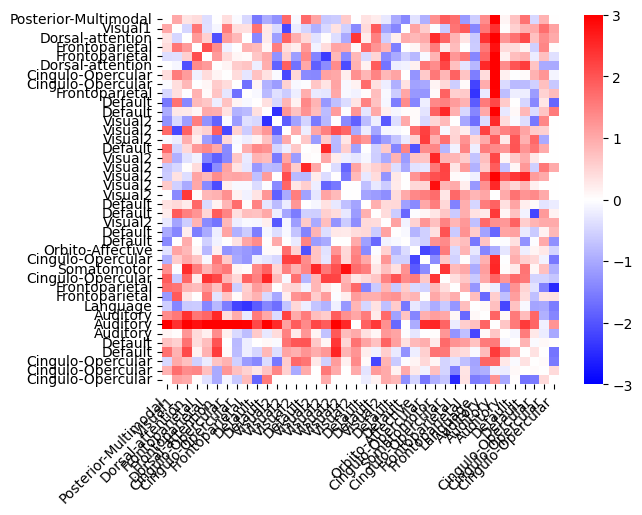

In [41]:
label_range = [140,180]#[40,70]
sns.heatmap(mat_tstats_comp[label_range[0]:label_range[1],label_range[0]:label_range[1]],
              cmap = 'bwr', vmin=-3,vmax=3,
              xticklabels=atlas_names['label'][label_range[0]:label_range[1]],
              yticklabels=atlas_names['label'][label_range[0]:label_range[1]],)
plt.xticks(rotation=45, ha='right')



In [42]:
min_val = np.nanmin(mat_pvals)
positions = np.where(mat_pvals == min_val)
print(f'{min_val} at node combi {positions[0][0]} {positions[1][0]}')

mat_tstats[positions[0][0], positions[1][0]]

6.88628114357515e-05 at node combi 224 300


-4.344114881824661

In [43]:
min_val = np.nanmin(mat_tstats)
positions = np.where(mat_tstats == min_val)
print(f'{min_val} at node combi {positions[0][0]} {positions[1][0]}')

-4.344114881824661 at node combi 224 300


In [44]:
max_val = np.nanmax(mat_tstats)
positions = np.where(mat_tstats == max_val)
print(f'{max_val} at node combi {positions[0][0]} {positions[1][0]}')

4.266842247609298 at node combi 124 321


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


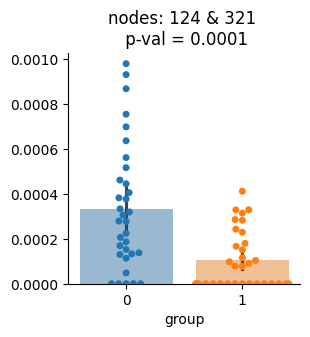

In [49]:
node1 = positions[0][0]
node2 = positions[1][0]

conn_weights = cms[:, node1, node2]
df = pd.DataFrame(np.array(conn_weights), index=sub_array, columns=[f'conn_weights'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)

n_dyads = 1
fig, axes = plt.subplots(1,n_dyads, figsize=(n_dyads*3 , 3)) # , sharex=True, sharey=True

sns.barplot(data=df.reset_index(), x ='group', hue='group',y='conn_weights', alpha=0.5,legend=False, ax=axes)
sns.swarmplot(data=df.reset_index(),  x ='group', hue='group',y='conn_weights', size=5,legend=False, ax=axes)

t_stat, p_val = ttest_ind(df.xs(0,0,'group')['conn_weights'], df.xs(1,0,'group')['conn_weights'], equal_var=False)  # Welch's t-test
p_val = np.round(p_val,5)
axes.set(title=f'nodes: {node1} & {node2} \n p-val = {p_val}', ylabel='')
sns.despine(ax=axes)

In [48]:
df

,,0
subject,group,
1,0,0.000000
2,1,0.000711
3,0,0.003977
4,1,0.002162
5,0,0.002505
...,...,...
62,0,0.003110
63,0,0.003526
64,0,0.001749
